# MenuGraph — Visualisation

**Data:** `menu_graph_v2_extracted.json`. Same graph model as agentic implementation (`experiments.models.menu_graph.MenuGraph`).

- **Incoming edges** on a recipe → how often it is served.
- **Outgoing edges** from a meal period → variety (number of recipes offered).

In [1]:
import sys
from pathlib import Path

candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
backend = next((p for p in candidates if (p / "experiments" / "menu_graph_v2_extracted.json").exists()), Path.cwd())

if str(backend) not in sys.path:
    sys.path.insert(0, str(backend))

from experiments.models.menu_graph import MenuGraph

path = backend / "experiments" / "menu_graph_v2_extracted.json"
graph = MenuGraph.from_json_path(path)
meta = graph.graph_metadata

print(f"Loaded: {meta.description} — {meta.cycle}")
print(f"Nodes: {len(graph.nodes)}, Edges: {len(graph.edges)}")


ModuleNotFoundError: No module named 'loguru'

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

G = nx.DiGraph()

for n in graph.nodes:
    label = getattr(n, "name", None) or getattr(n, "kind", None) or getattr(n, "id", "unknown")
    G.add_node(n.id, node_type=n.type, label=label)

for e in graph.edges:
    G.add_edge(e.source, e.target, relationship=e.relationship)

# Layered hierarchy for readability.
layer_order = {
    "Station": 0,
    "Day": 1,
    "MealPeriod": 2,
    "Recipe": 3,
    "Instruction": 4,
    "Equipment": 4,
    "Ingredient": 5,
}

layers = {i: [] for i in range(6)}
for n, data in G.nodes(data=True):
    layer = layer_order.get(data.get("node_type", "Ingredient"), 5)
    layers[layer].append(n)

# Stable sorting improves visual consistency between runs.
for layer in layers:
    layers[layer].sort(key=lambda n: str(G.nodes[n].get("label", n)).lower())

pos = {}
max_len = max(len(v) for v in layers.values()) if layers else 1
x_spacing = 2.8
for layer, nodes_in_layer in layers.items():
    if not nodes_in_layer:
        continue
    n = len(nodes_in_layer)
    if n == 1:
        ys = [0.0]
    else:
        ys = [((n - 1) / 2.0 - i) * (max_len / n) for i in range(n)]
    x = layer * x_spacing
    for node, y in zip(nodes_in_layer, ys):
        pos[node] = (x, y)

type_color = {
    "Station": "#c0392b",
    "Day": "#1f77b4",
    "MealPeriod": "#2ca02c",
    "Recipe": "#ff7f0e",
    "Equipment": "#9467bd",
    "Instruction": "#8c564b",
    "Ingredient": "#95a5a6",
}

type_size = {
    "Station": 1700,
    "Day": 1050,
    "MealPeriod": 1000,
    "Recipe": 620,
    "Equipment": 460,
    "Instruction": 420,
    "Ingredient": 220,
}

colors = [type_color.get(G.nodes[n].get("node_type", ""), "#7f8c8d") for n in G.nodes]
sizes = [type_size.get(G.nodes[n].get("node_type", ""), 240) for n in G.nodes]

plt.figure(figsize=(28, 18))
nx.draw_networkx_edges(
    G,
    pos,
    edge_color="#9aa0a6",
    alpha=0.17,
    arrows=False,
    width=0.7,
)
nx.draw_networkx_nodes(
    G,
    pos,
    node_color=colors,
    node_size=sizes,
    edgecolors="#2f3640",
    linewidths=0.25,
)

nx.draw_networkx_labels(
    G,
    pos,
    labels={n: G.nodes[n].get("label", n) for n in G.nodes},
    font_size=5,
    font_color="#1f2937",
)

legend_handles = [
    Line2D([0], [0], marker="o", color="w", label=t, markerfacecolor=c, markeredgecolor="#2f3640", markersize=8)
    for t, c in type_color.items()
]
plt.legend(handles=legend_handles, loc="upper right", frameon=True, framealpha=0.9, title="Node Type")

plt.title(f"{meta.cycle}\nComplete Enriched Graph (v2, Layered Hierarchy)", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()



ModuleNotFoundError: No module named 'matplotlib'

## Traversal: incoming / outgoing counts

`graph.count_incoming(node_id)`, `graph.count_outgoing(node_id)`, `graph.recipe_serve_count(recipe_id)`, `graph.period_variety_count(period_id)`.

In [3]:
print("Recipe serve counts (incoming edges = how often served):")
for r in graph.get_recipes()[:8]:
    c = graph.recipe_serve_count(r.id)
    print(f"  {r.name}: {c}")
print("\nPeriod variety (outgoing edges = number of recipes offered):")
for p in graph.get_meal_periods():
    c = graph.period_variety_count(p.id)
    print(f"  {p.name}: {c}")

Recipe serve counts (incoming edges = how often served):


NameError: name 'graph' is not defined

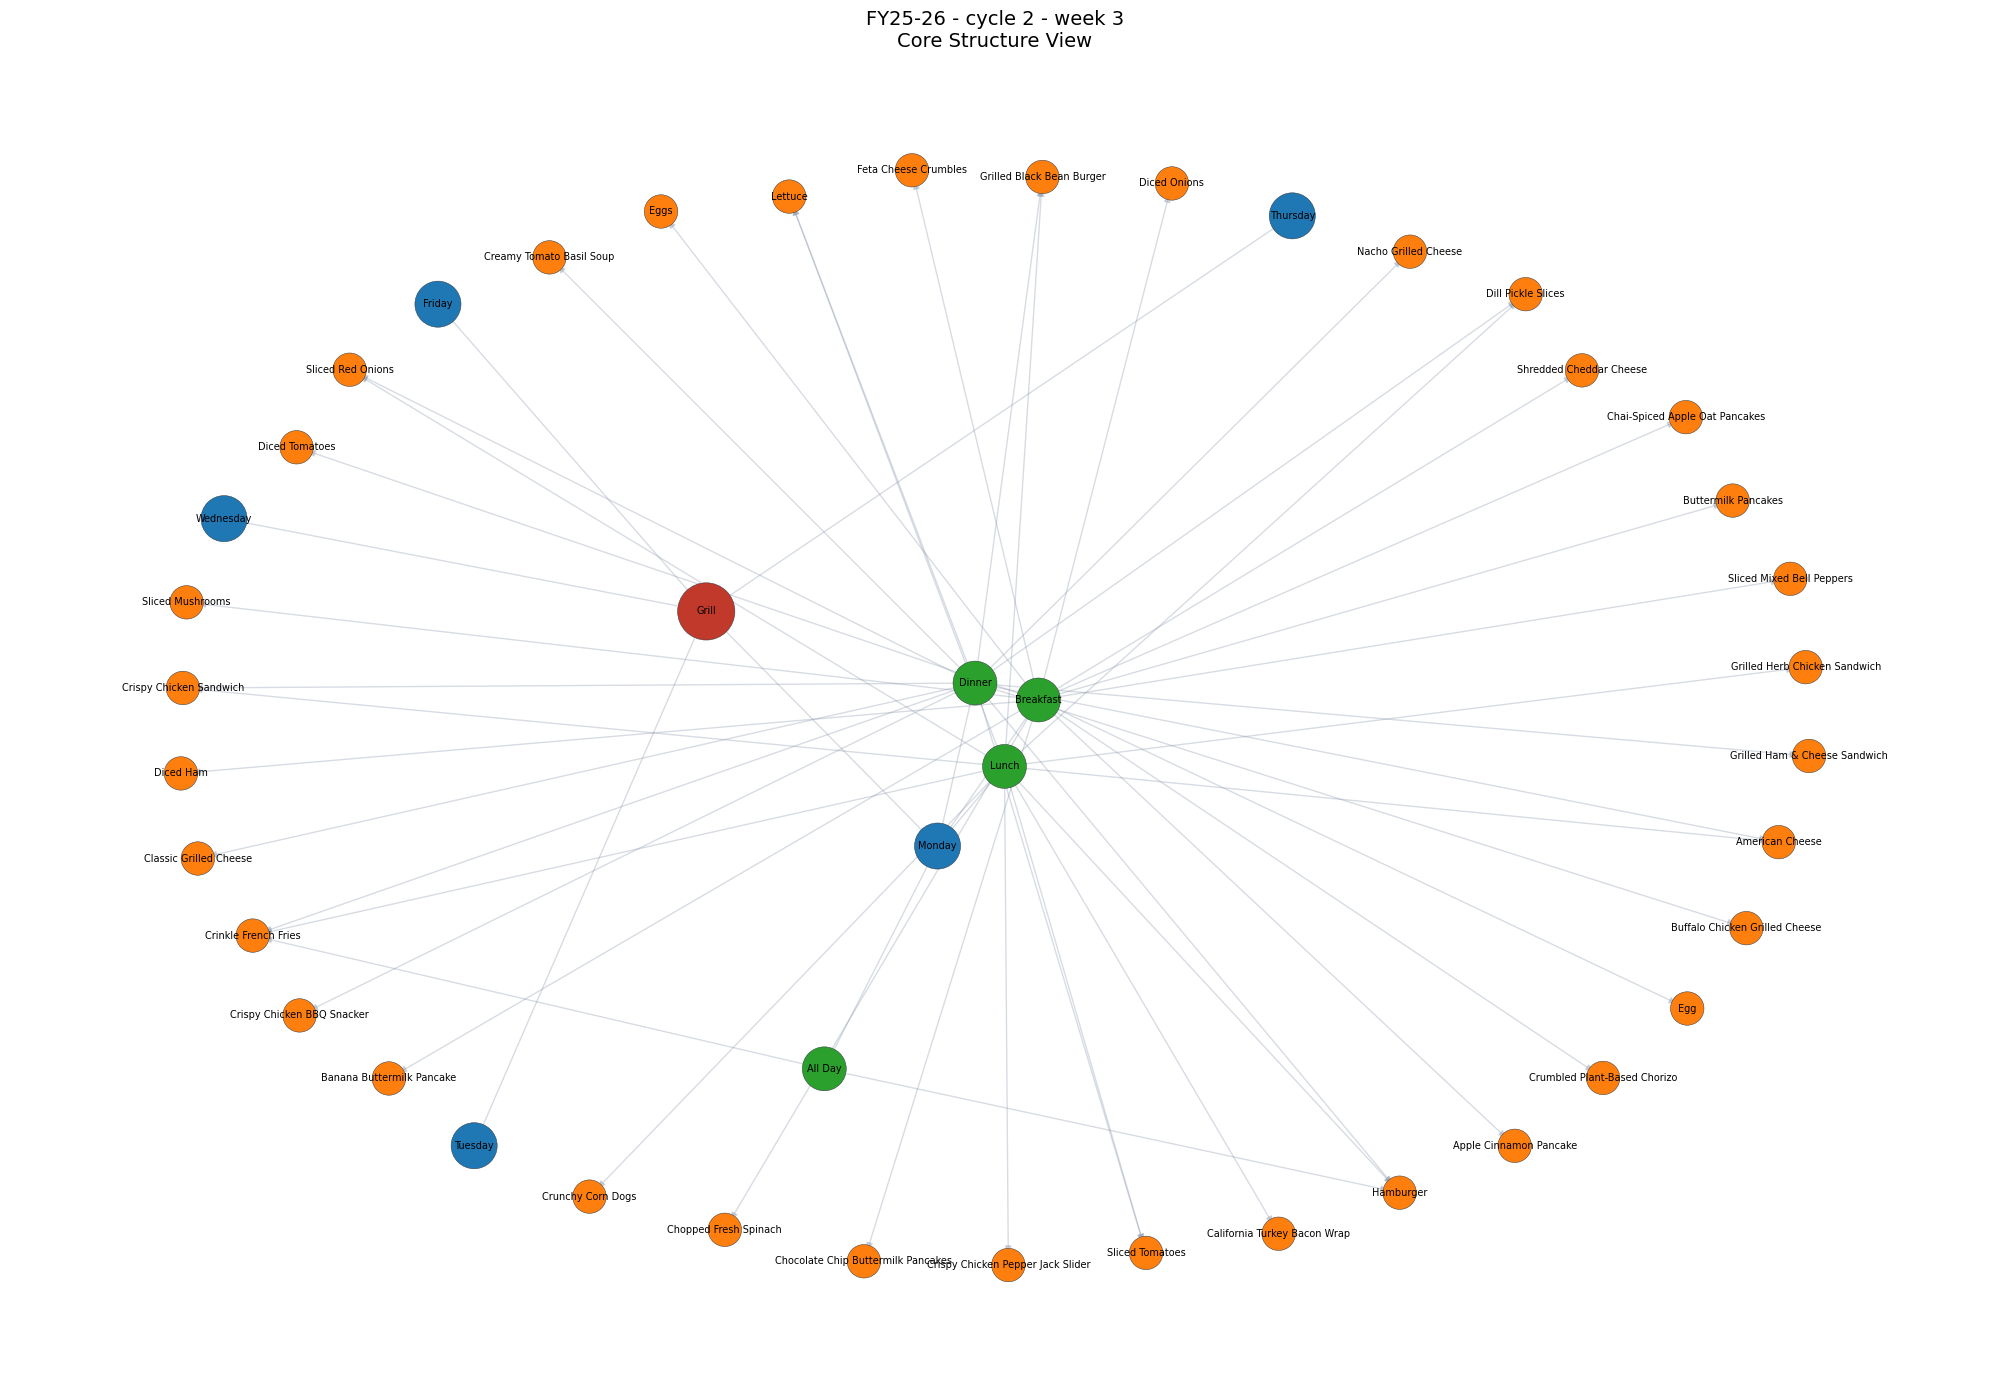

In [9]:
# Core structure view (station/day/meal period/recipe only) for readability.
core_types = {"Station", "Day", "MealPeriod", "Recipe"}

H = nx.DiGraph()
for n in graph.nodes:
    if n.type in core_types:
        label = getattr(n, "name", None) or getattr(n, "id", "unknown")
        H.add_node(n.id, node_type=n.type, label=label)

for e in graph.edges:
    if e.source in H and e.target in H:
        H.add_edge(e.source, e.target, relationship=e.relationship)

core_color = {
    "Station": "#c0392b",
    "Day": "#1f77b4",
    "MealPeriod": "#2ca02c",
    "Recipe": "#ff7f0e",
}
core_size = {
    "Station": 1700,
    "Day": 1100,
    "MealPeriod": 1000,
    "Recipe": 580,
}

colors = [core_color.get(H.nodes[n]["node_type"], "#7f8c8d") for n in H.nodes]
sizes = [core_size.get(H.nodes[n]["node_type"], 500) for n in H.nodes]

pos = nx.spring_layout(H, k=1.7, seed=42, iterations=300)

plt.figure(figsize=(20, 14))
nx.draw_networkx_edges(H, pos, edge_color="#8d99ae", alpha=0.35, arrows=True, arrowsize=10, width=1.0)
nx.draw_networkx_nodes(H, pos, node_color=colors, node_size=sizes, edgecolors="#2f3640", linewidths=0.35)
nx.draw_networkx_labels(H, pos, labels={n: H.nodes[n]["label"] for n in H.nodes}, font_size=7)

plt.title(f"{meta.cycle}\nCore Structure View", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()



In [ ]:
# Separate station-based subgraphs for Breakfast, Lunch, and Dinner (new cell, existing cells unchanged)
import networkx as nx
import matplotlib.pyplot as plt


def build_period_subgraph(graph, period_name: str) -> nx.DiGraph:
    G = nx.DiGraph()

    station = graph.get_station()
    if not station:
        return G

    # Include station node
    G.add_node(station.id, node_type=station.type, label=getattr(station, "name", station.id))

    for day in graph.get_days_for_station():
        # Find the period node for this day matching period_name
        periods = graph.get_periods_for_day(day.id)
        target_period = next((p for p in periods if p.name.lower() == period_name.lower()), None)
        if target_period is None:
            continue

        # Core chain: Station -> Day -> Period
        G.add_node(day.id, node_type=day.type, label=getattr(day, "name", day.id))
        G.add_node(target_period.id, node_type=target_period.type, label=getattr(target_period, "name", target_period.id))
        G.add_edge(station.id, day.id, relationship="HAS_SCHEDULE")
        G.add_edge(day.id, target_period.id, relationship="HAS_PERIOD")

        # Recipes served in this period
        recipes = graph.get_recipes_for_period(target_period.id)
        for r in recipes:
            G.add_node(r.id, node_type=r.type, label=getattr(r, "name", r.id))
            G.add_edge(target_period.id, r.id, relationship="SERVES_RECIPE")

            # Utensil/equipment + ingredient neighbors from v2 graph
            for e in graph.get_edges_from(r.id):
                if e.relationship not in {"USES_UTENSIL", "HAS_INGREDIENT", "USES_EQUIPMENT", "USES_INGREDIENT"}:
                    continue
                t = graph.get_node(e.target)
                if t is None:
                    continue
                lbl = getattr(t, "name", None) or getattr(t, "kind", None) or t.id
                G.add_node(t.id, node_type=t.type, label=lbl)
                G.add_edge(r.id, t.id, relationship=e.relationship)

    return G


def plot_subgraph(G: nx.DiGraph, title: str) -> None:
    if len(G.nodes) == 0:
        print(f"No data for {title}")
        return

    type_color = {
        "Station": "#c0392b",
        "Day": "#1f77b4",
        "MealPeriod": "#2ca02c",
        "Recipe": "#ff7f0e",
        "Equipment": "#9467bd",
        "Instruction": "#8c564b",
        "Ingredient": "#95a5a6",
    }
    type_size = {
        "Station": 1400,
        "Day": 900,
        "MealPeriod": 850,
        "Recipe": 520,
        "Equipment": 400,
        "Instruction": 360,
        "Ingredient": 200,
    }

    pos = nx.spring_layout(G, k=1.7, seed=42, iterations=250)
    colors = [type_color.get(G.nodes[n].get("node_type", ""), "#7f8c8d") for n in G.nodes]
    sizes = [type_size.get(G.nodes[n].get("node_type", ""), 220) for n in G.nodes]

    plt.figure(figsize=(18, 12))
    nx.draw_networkx_edges(G, pos, edge_color="#9aa0a6", alpha=0.22, arrows=False, width=0.8)
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=sizes, edgecolors="#2f3640", linewidths=0.25)
    nx.draw_networkx_labels(G, pos, labels={n: G.nodes[n].get("label", n) for n in G.nodes}, font_size=6)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


for meal in ["Breakfast", "Lunch", "Dinner"]:
    sub = build_period_subgraph(graph, meal)
    print(f"{meal}: nodes={len(sub.nodes)}, edges={len(sub.edges)}")
    plot_subgraph(sub, f"{meta.cycle} — {meal} Subgraph")



: 